<a href="https://colab.research.google.com/github/ushasri0412/Data-Science-Task/blob/main/Heart_problem_detection_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HEART PROBLEMS DETECTION**

In [11]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer

In [12]:
df=pd.read_csv("/content/heart.csv")
df

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


<Axes: xlabel='sex', ylabel='Count'>

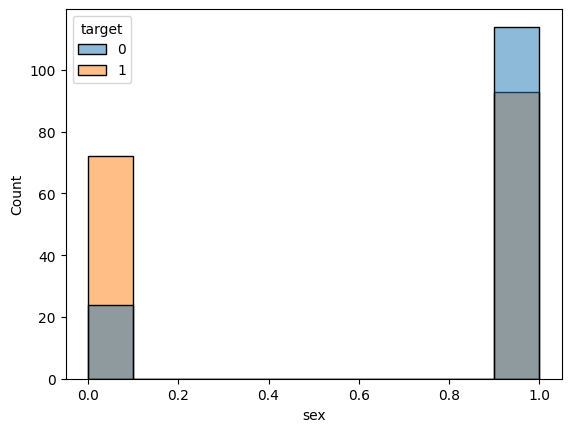

In [13]:
sns.histplot(x="sex",data=df,hue="target")

In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0


In [15]:
df.drop_duplicates()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [16]:
df.drop("Unnamed: 0",axis=1,inplace=True)

([<matplotlib.patches.Wedge at 0x7dff297162d0>,
 [Text(-0.15346694397759053, 1.0892418909985877, 'Male'),
  Text(0.15346716904989344, -1.0892418592873723, 'Female')],
 [Text(-0.08370924216959483, 0.5941319405446842, '54.46%'),
  Text(0.0837093649363055, -0.5941319232476575, '45.54%')])

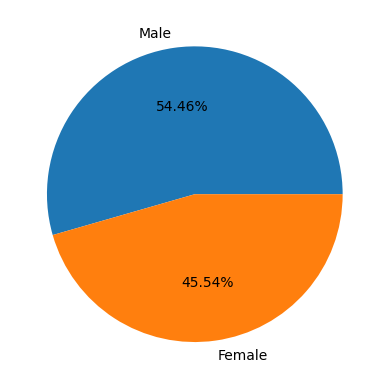

In [17]:
df.target.value_counts()
plt.pie(df.target.value_counts(),labels=["Male","Female"],autopct="%0.2f%%")


<Axes: xlabel='trestbps', ylabel='Count'>

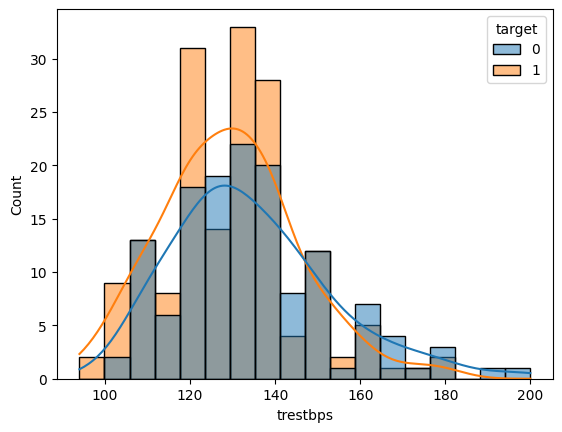

In [18]:
sns.histplot(x="trestbps",data=df,hue="target",kde=True)

<Axes: xlabel='age', ylabel='Count'>

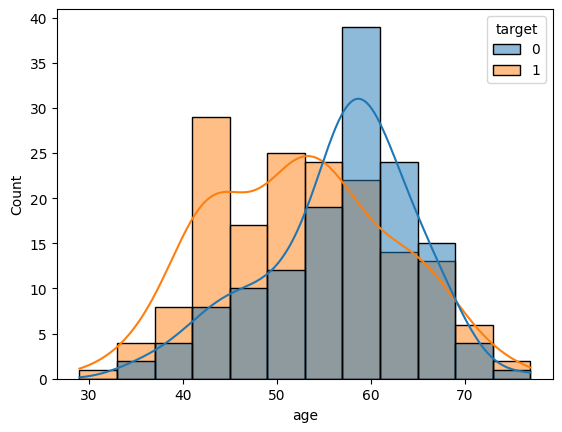

In [19]:
sns.histplot(x="age",data=df,hue="target",kde=True)

In [20]:
#Divide data into input and output
x=df.drop("target",axis=1)
y=df["target"]


In [21]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(x, y, test_size=0.3,random_state=42)


In [22]:
#logistic regression
model=LogisticRegression()
model.fit(Xtrain,Ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [23]:
ypred = model.predict(Xtest)
ypred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1])

In [24]:
confusion_matrix(Ytest,ypred)

array([[32,  9],
       [ 8, 42]])

In [26]:
print(classification_report(Ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



In [27]:
print("Trainig Eff: ",model.score(Xtrain,Ytrain))
print("Testing Eff: ",model.score(Xtest,Ytest))

Trainig Eff:  0.8679245283018868
Testing Eff:  0.8131868131868132


In [29]:
#New input
# Calculated for 2 inputs
new_data=df.iloc[:2,:-1]
pred=model.predict(new_data)[0]
prob=model.predict_proba(new_data)
if pred ==0:
  print("No HEART DISEASE")
else:
  print("HEART DISEASE")
print("Probability: ",prob)

HEART DISEASE
Probability:  [[0.12958216 0.87041784]
 [0.45209214 0.54790786]]
